In [1]:
""" 
Multi-Head Latent attention increases attentions arithmetic intensity by compressing 
the kv cache inside low-rank matrices. As far as I understand that's the same technique
that enables LoRA to finetune all parameters but using LoR matrices and (my guess) 
applying an outer product to obtain the full number parameters back (or attention heads
with their respective kv-caches.) An important detail is that storing the kv cache as loR
matrices does not decrease the memory footprint but rather 
"""

" \nMulti-Head Latent attention increases attentions arithmetic intensity by compressing \nthe kv cache inside low-rank matrices. As far as I understand that's the same technique\nthat enables LoRA to finetune all parameters but using LoR matrices and (my guess) \napplying an outer product to obtain the full number parameters back (or attention heads\nwith their respective kv-caches.) An important detail is that storing the kv cache as loR\nmatrices does not decrease the memory footprint but rather \n"

In [ ]:
import torch
from torch import nn
import math

class Multihead_Latent_Attention(nn.Module):
    def __init__(self):
        
        self.dim = 2
        self.n_heads = 2
        self.q_lora_rank = 2
        self.kv_lora_rank = 2
        self.qk_nope_head_dim = 2
        self.qk_rope_head_dim = 2
        self.qk_head_dim = self.qk_nope_head_dim + self.qk_rope_head_dim
        self.v_head_dim = 2
        
        self.rope = 1
        self.max_seq_len = 100
        self.original_seq_len = 90

        # query stuff
        self.wq_a = nn.Linear(self.dim, self.q_lora_rank, bias=False)
        # TODO check what epsilon value is plausible
        self.q_norm = nn.RMSNorm(self.q_lora_rank, eps=0.1)
        self.wq_b = nn.Linear(self.q_lora_rank, self.n_heads * self.qk_head_dim, bias=False)

        self.wkv_a = nn.Linear(
            self.dim, self.kv_lora_rank + self.qk_rope_head_dim, bias=False
        )
        self.kv_norm = nn.RMSNorm(self.kv_lora_rank, eps=self.norm_eps)
        self.wkv_b = nn.Linear(
            self.kv_lora_rank,
            self.n_heads * (self.qk_nope_head_dim + self.v_head_dim),
            bias=False,
        )
        self.wo = nn.Linear(self.n_heads * self.v_head_dim, self.dim, bias=False)
        self.softmax_scale = self.qk_head_dim**-0.5

        if self.max_seq_len > self.original_seq_len:
            mscale = 0.1 * mscale * math.log(self.rope_factor) + 1.0
            self.softmax_scale = self.softmax_scael * mscale * mscale

        self.inner_attention = attention()

    def forward(self, x: torch.Tensor, freq_cis: torch.Tensor):
        batch_size, seq_len, _ = x.size()

        # Query projection
        if self.q_lora_rank == 0:
            q = self.wq(x)
        else:
            q = self.wq_a(x)
            q = self.wq_b(self.q_norm(q))

        # q: [batch_size, seq_len, n_heads, qk_head_dim]
        q = q.view(batch_size, seq_len, -1, self.qk_head_dim)
        # q_nope: [batch_size, seq_len, n_heads, qk_nope_head_dim]
        # q_ro: [batch_size, seq_len, n_heads, qk_rope_head_dim]
        q_nope, q_pe = torch.split(q, [self.qk_nope_head_dim, self.qk_rope_head_dim], dim=-1)

        q_pe = apply_rotary_emb(q_pe, freq_cis)
        q = torch.cat([q_nope, q_pe], dim=-1)

        # key-value projection
        # kv_a: [batch_size, seq_len, kv_lora_rank + qk_rope_head_dim]
        kv_a = self.wkv_a(x)

        # k_pe: [b, s, qk_rope_head_dim]
        # c_kv: [b, s, kv_lora_rank]
        k_pe, c_kv = torch.split(kv_a, [self.qk_rope_head_dim, self.kv_lora_rank], dim=-1)

        # k_pe: [b, s, 1, qk_rope_head_dim]
        k_pe = apply_rotary_emb(q_pe.unsqueeze(2), freq_cis)

        # up projection to rebuild the full KV the
        # up projection also contains W_V, which is usually kept seperate
        # kv: [b, s, n_heads * kv_headdim]
        kv = self.wkv_b(self.kv_norm(c_kv))

        # kv: [b, s, n_heads, k_h_d, v_h_d]
        kv = kv.view(batch_size, seq_len, -1, self.qk_head_dim + self.v_head_dim)

        # v: [b, s, n_h, v_head_dim]
        # k_nope: [b, s, n_h, qk_head_dim]
        k_nope, v = kv.slit([self.qk_nope_head_dim, self.v_head_dim], dim=-1)
    
        # k: [b, s, n_h, qk_head_dim]
        k = torch.cat([k_pe, k_pe.expand(-1, -1, self.n_heads, -1)], dim=-1)

        # q: [b, n_h, s, qk_/v_dim]
        # seperate n_h into earlier dimension turns it into a "batch" dim and seperates the heads logically 
        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        o = self.inner_attention(q, k, v, scale=self.softmax_scale)
        # o: [b, s, h, v_head_dim]
        o = o.transpose(1, 2).contigious()
        # o: [b, s, h * v_head_dim]
        o = o.view(batch_size, seq_len, -1)
        # return: [b, s, dim]
        return self.wo(o)

    @torch.no_grad()
    def absorb_mla_weights(self) -> None:
        n_heads = self.n_heads
        dim= self.dim
        q_lora_rank = self.q_lora_rank
        qk_nope_head_dim = self.qk_nope_head_dim
        qk_rope_head_dim = self.qk_rope_head_dim
        v_head_dim = self.v_head_dim
        kv_lora_rank = self.kv_lora_rank

        device = self.wq.weight.device
        dtype = self.wq.weight.dtype

        wq_nope, wq_rope = self.wq.weight.view(
            n_heads,
            qk_nope_head_dim + qk_rope_head_dim
            dim,
        )
        wkv_b = self.wkv_b.weight.view(
            n_heads, 
            qk_nope_head_dim + v_head_dim
            kv_lora_rank
        )
        # qk_rope: [n_heads, qk_nope_head, dim]
        # qk_rope: [n_heads, qk_rope_head, dim]
        w_uk, w_uv = torch.split(
            wkv_b,
            [qk_nope_head_dim, qk_rope_head_dim],
            dim=1,
        )

Diagram showing the MLA archticture

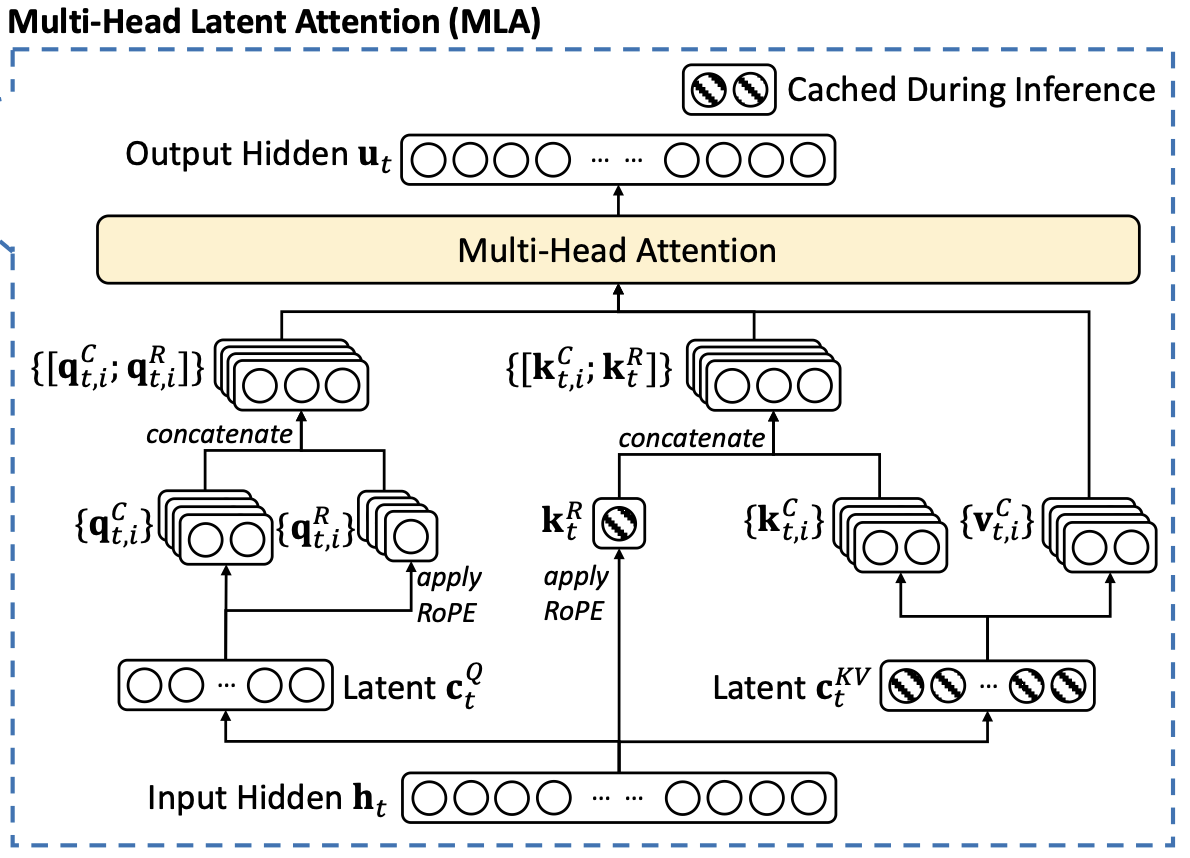